In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 5: Putting it all together 
### Associated lectures: All material till lecture 13 

<div class="alert-warning">
    
## Instructions  
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Before you start  

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
  
- Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   
### Before submitting  

- **Run all cells** (▶▶ button) to ensure the notebook executes cleanly from top to bottom.

  - Execution counts must start at **1** and be sequential.
    
  - Notebooks with missing outputs or errors may lose marks.

- **Do not upload or push data files** used in this lab to GitHub or Gradescope. (A `.gitignore` is provided to prevent this.)  


### Submitting on Gradescope  

- Upload **only** your `.ipynb` file (with outputs shown) and any required output files. Do **not** submit extra files.
  
- If needed, refer to the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- If your notebook is too large to render, also upload a **Web PDF** or **HTML** version.  
  - You can create one using **File $\rightarrow$ Save and Export Notebook As**.  
  - If you get an error when creating a PDF, try running the following commands in your lab directory:  

    ```bash
    conda install -c conda-forge nbconvert-playwright
    jupyter nbconvert --to webpdf lab1.ipynb
    ```  

  - Ensure all outputs are visible in your PDF or HTML file; TAs cannot grade your work if outputs are missing.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.feature_selection import RFECV

from sklearn.metrics import roc_auc_score, f1_score, classification_report

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

import shap

<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

In this mini project, you have the option to choose on which dataset you will be working on. The tasks you will need to carry on will be similar, independently of your choice.

### Option 1
You can choose to work on a classification problem of predicting whether a credit card client will default or not. 
For this problem, you will use [Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset). In this data set, there are 30,000 examples and 24 features, and the goal is to estimate whether a person will default (fail to pay) their credit card bills; this column is labeled "default.payment.next.month" in the data. The rest of the columns can be used as features. You may take some ideas and compare your results with [the associated research paper](https://www.sciencedirect.com/science/article/pii/S0957417407006719), which is available through [the UBC library](https://www.library.ubc.ca/). 


### Option 2
You can choose to work on a regression problem using a [dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data) of New York City Airbnb listings from 2019. As usual, you'll need to start by downloading the dataset, then you will try to predict `reviews_per_month`, as a proxy for the popularity of the listing. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts create more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features were are using in `listings.csv.gz` for the New York city datasets. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.


<div class="alert alert-info">
    
**Your tasks:**

1. Review the available datasets and choose the one you find most interesting. It may help to read through the dataset documentation on Kaggle before deciding.
2. Once you've selected a dataset, take time to understand the problem it represents and the meaning of each feature. Use the Kaggle documentation to guide you.
3. Download the dataset and load it into a pandas DataFrame.
4. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>

<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

I selected option 1, exploring credit card information and predicting wheather a client will default or not. 

Looking at the dataset, features include personal information:
- LIMIT_BAL
- SEX
- EDUCATION
- MARRIAGE
- AGE

It also includes repayment history, bill amounts and payment armounts for 6 months:
- PAY
- BILL_AMT 
- PAY_AMT

Through early analysis, it seems that PAY will be a important feature that can aid in predictions as it represents status in a particular month:
- (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)

A notable concern, however, is the possibility of class imbalance as credit card defaults are typically less-common. As such, accuracy alone may not be a sufficient metric, and measures like precision, recall, or ROC-AUC will be important. Additionally, we should probably scale all of these values to normalize the data set so that we can develop a stronger prediction model. Looking at the loaded dataframe as well, ID should not influence model building as it is treated as a index instead of a column, and it does not need to be dropped.

In [3]:
credit_card_df = pd.read_csv("data/UCI_Credit_Card.csv", index_col=0)
display(credit_card_df)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29996,220000.0,1,3,1,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29997,150000.0,1,3,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29998,30000.0,1,2,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [4]:
X = credit_card_df.drop(columns=["default.payment.next.month"])
y = credit_card_df["default.payment.next.month"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
X_train

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
ID,,,,,,,,,,,,,,,,,,,,,
16396,320000.0,2,1,2,36,0,0,0,0,0,...,28695.0,19370.0,10155.0,3788.0,5000.0,5018.0,1000.0,3000.0,0.0,7013.0
21449,440000.0,2,1,2,30,-1,-1,-1,0,0,...,87426.0,171244.0,150897.0,117870.0,612.0,87426.0,130007.0,3018.0,15000.0,51663.0
20035,160000.0,2,3,1,44,-2,-2,-2,-2,-2,...,-18.0,-18.0,-18.0,-18.0,0.0,0.0,0.0,0.0,0.0,0.0
25756,120000.0,2,2,1,30,0,0,0,0,0,...,104694.0,103058.0,71095.0,47379.0,3706.0,5502.0,4204.0,3017.0,2005.0,1702.0
1439,50000.0,1,2,2,54,1,2,0,0,0,...,27168.0,27585.0,27910.0,27380.0,0.0,1400.0,1200.0,1500.0,1000.0,1500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28637,380000.0,2,2,1,37,0,0,0,0,0,...,13277.0,14291.0,15949.0,15556.0,1204.0,1300.0,1242.0,1900.0,0.0,3000.0
17731,360000.0,2,1,1,54,1,-2,-2,-1,0,...,0.0,2580.0,2580.0,6941.0,0.0,0.0,2580.0,0.0,6941.0,0.0
28031,50000.0,2,3,1,29,0,0,0,0,0,...,46777.0,39420.0,8824.0,9009.0,2002.0,2000.0,1530.0,1000.0,327.0,329.0


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

In [5]:
print(X_train.describe().round(2))
print("Gives insight into basic statistics of the data set")
print()

        LIMIT_BAL       SEX  EDUCATION  MARRIAGE       AGE     PAY_0  \
count    21000.00  21000.00   21000.00  21000.00  21000.00  21000.00   
mean    167880.65      1.60       1.85      1.55     35.50     -0.02   
std     130202.68      0.49       0.79      0.52      9.21      1.12   
min      10000.00      1.00       0.00      0.00     21.00     -2.00   
25%      50000.00      1.00       1.00      1.00     28.00     -1.00   
50%     140000.00      2.00       2.00      2.00     34.00      0.00   
75%     240000.00      2.00       2.00      2.00     41.00      0.00   
max    1000000.00      2.00       6.00      3.00     79.00      8.00   

          PAY_2     PAY_3     PAY_4     PAY_5  ...  BILL_AMT3  BILL_AMT4  \
count  21000.00  21000.00  21000.00  21000.00  ...   21000.00   21000.00   
mean      -0.14     -0.17     -0.23     -0.26  ...   47010.41   43486.61   
std        1.19      1.20      1.17      1.14  ...   69035.76   64843.30   
min       -2.00     -2.00     -2.00     -2.00  

In [6]:
print(X_train.info())
print("Shows the data type for each feature")
print()

<class 'pandas.core.frame.DataFrame'>
Index: 21000 entries, 16396 to 19967
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  21000 non-null  float64
 1   SEX        21000 non-null  int64  
 2   EDUCATION  21000 non-null  int64  
 3   MARRIAGE   21000 non-null  int64  
 4   AGE        21000 non-null  int64  
 5   PAY_0      21000 non-null  int64  
 6   PAY_2      21000 non-null  int64  
 7   PAY_3      21000 non-null  int64  
 8   PAY_4      21000 non-null  int64  
 9   PAY_5      21000 non-null  int64  
 10  PAY_6      21000 non-null  int64  
 11  BILL_AMT1  21000 non-null  float64
 12  BILL_AMT2  21000 non-null  float64
 13  BILL_AMT3  21000 non-null  float64
 14  BILL_AMT4  21000 non-null  float64
 15  BILL_AMT5  21000 non-null  float64
 16  BILL_AMT6  21000 non-null  float64
 17  PAY_AMT1   21000 non-null  float64
 18  PAY_AMT2   21000 non-null  float64
 19  PAY_AMT3   21000 non-null  float64
 20  PAY_AMT

In [7]:
print(X_train.isnull().sum())
print("No missing values were found across any features, indicating the dataset is complete and no imputation is required.")


LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
dtype: int64
No missing values were found across any features, indicating the dataset is complete and no imputation is required.


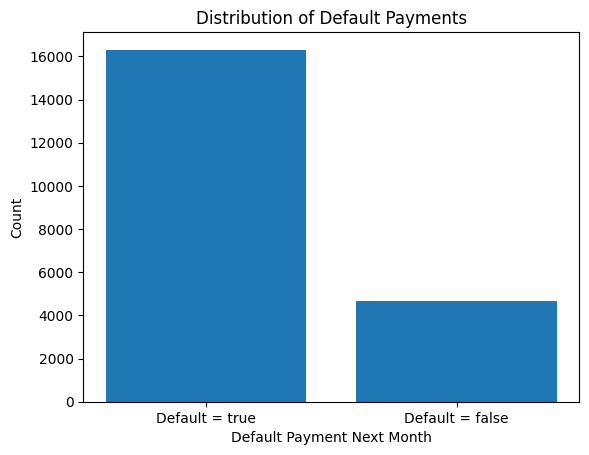

In [8]:
plt_x = ["Default = true","Default = false"]
plt_y = y_train.value_counts().sort_index()
plt.bar(plt_x, plt_y)
plt.xlabel("Default Payment Next Month")
plt.ylabel("Count")
plt.title("Distribution of Default Payments")
plt.show()

"Distribution of Default Payments"
Provides statistical confirmation about doubts of class imbalance raised earlier. 

Text(0.5, 0, 'Age')

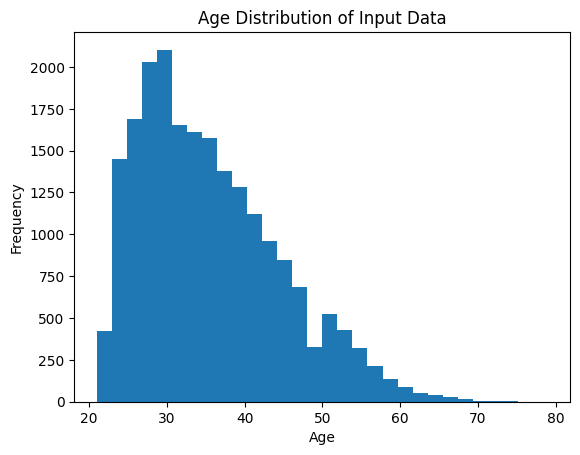

In [9]:
X_train["AGE"].plot.hist(bins=30)
plt.title("Age Distribution of Input Data")
plt.xlabel("Age")

"Age Distribution of Input Data"
Indicates that the data is skewed towards a younger age population, perhaps indicating poor data collection practices as younger people tend to have worse spending habits. Leading to higher chances of defaults. 

4. 
The two appropraite metrics to use to sure model performance are Recall and ROC-AUC. 

Recall measures how many actual defaults the model correctly identifies. In this context, a false negative is more costly than a false positive. Therefore, maximizing recall is prioritized over raw accuracy.

ROC-AUC measures the area under the curve of a ROC graph and indicates the model's ability to distinguish between defaulters and non-defaulters across all classification thresholds. ROC-AUC is also robust in dealing with class-imbalanced data sets like what we have, so it will be suitable to utilize.

Notably, accuracy is most definately not an appropraite metric to measure performance. This is clearly observable in a dummy classifier, as when we conduct .fit() and .predict(), it will naturally high due to the significant class imbalance we have. 

However, for the sake of simplicity when training the models, and to make the model building process to be more interpretable, I will only be using ROC-AUC as it is able to give a holistic view of model performance across thresholds. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

In [10]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

# appl to training set
X_train["delinquency_count"] = (X_train[pay_cols] > 0).sum(axis=1)
X_train["avg_bill_amt"] = X_train[bill_cols].mean(axis=1)
X_train["avg_pay_amt"] = X_train[pay_amt_cols].mean(axis=1)
X_train["credit_utilization"] = X_train["BILL_AMT1"] / (X_train["LIMIT_BAL"] + 1)

# apply to test set
X_test["delinquency_count"] = (X_test[pay_cols] > 0).sum(axis=1)
X_test["avg_bill_amt"] = X_test[bill_cols].mean(axis=1)
X_test["avg_pay_amt"] = X_test[pay_amt_cols].mean(axis=1)
X_test["credit_utilization"] = X_test["BILL_AMT1"] / (X_test["LIMIT_BAL"] + 1)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

Feature types:
- LIMIT_BAL = numerical (continuous) -> StandardScaler
- SEX = categorical (binary) -> OneHotEncoder  with (drop="if_binary")
- EDUCATION = numerical (ordinal) -> StandardScaler after being mapped
- MARRIAGE = categorical (nominal) -> OneHotEncoder
- AGE = numerical (continuous) -> StandardScaler
- PAY_ = ordinal (repayment status: -2 to 8) -> StandardScaler
- PAY_AMT_ = numerical (continuous) -> StandardScaler
- BILL_AMT_: Numerical (continuous) -> StandardScaler
- delinquency_count = numerical (discrete count) -> StandardScaler
- avg_bill_amt = numerical (continuous) -> StandardScaler
- avg_pay_amt = numerical (continuous) -> StandardScaler
- credit_utilization = numerical (continuous ratio) -> StandardScaler

In [11]:
# 6,5,4 (Others/Unknown) = 0
#  3 (HS) = 1
# 2 (Uni) = 2
# 1 (Grad) = 3

edu_mapping = {6: 0, 5: 0, 4: 0, 0: 0, 3: 1, 2: 2, 1: 3}

X_train['EDUCATION'] = X_train['EDUCATION'].map(edu_mapping).fillna(0)
X_test['EDUCATION'] = X_test['EDUCATION'].map(edu_mapping).fillna(0)

numerical_features = [
    "LIMIT_BAL", "AGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    "delinquency_count", "avg_bill_amt", "avg_pay_amt", "credit_utilization",
    "EDUCATION"
]

categorical_features = ["SEX", "MARRIAGE"]

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), numerical_features),
        ("nominal", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_features)
    ]
)


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [12]:
dummy = DummyClassifier()
dummy.fit(X_train, y_train)
score = dummy.score(X_test, y_test)

print("Dummy score: " + str(score))

Dummy score: 0.7835555555555556


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

In [13]:
lr_pipe = Pipeline([("preprocessor", preprocessor), ("classifier", LogisticRegression(max_iter=1000, random_state=123))])

In [14]:
param_grid = {"classifier__C": [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    lr_pipe,
    param_grid,
    cv=5,
    scoring="roc_auc",
    return_train_score=True
)

grid_search.fit(X_train, y_train)
best_lr = grid_search.best_estimator_


In [15]:
cv_scores = cross_validate(best_lr, X_train, y_train, cv=5, scoring="roc_auc", return_train_score=True)

In [16]:

print(pd.DataFrame(cv_scores))
print("Mean test score : " + str(cv_scores["test_score"].mean()))
print("Score std: " + str(cv_scores["test_score"].std()))

   fit_time  score_time  test_score  train_score
0  0.032800    0.003862    0.741337     0.759130
1  0.036736    0.003397    0.749613     0.758314
2  0.030280    0.003446    0.763310     0.755397
3  0.067086    0.004295    0.762785     0.756249
4  0.032695    0.003491    0.757374     0.755525
Mean test score : 0.7548838507999023
Score std: 0.008377666935319212


Overall, the linear model seems to perform well. There is little to no variance between test_score and train_score, meaning there is no possibility of overfitting. Additionally, the fit time for linear regression is reasonable and the score time is exceptionally quick. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

In [17]:
dt_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=123))
])

dt_cv = cross_validate(dt_pipe, X_train, y_train, cv=5, scoring="roc_auc", return_train_score=True)
print("Decision Tree")
dt_results = pd.DataFrame(dt_cv)
print(dt_results)

dt_means = dt_results.mean()

print("\nAverage Across 5 Folds:")
print(dt_means)


Decision Tree
   fit_time  score_time  test_score  train_score
0  0.279150    0.004640    0.623876     0.999999
1  0.260546    0.004283    0.621123     0.999999
2  0.260555    0.003720    0.605707     0.999999
3  0.265778    0.003610    0.626861     0.999998
4  0.284697    0.003654    0.607856     0.999999

Average Across 5 Folds:
fit_time       0.270145
score_time     0.003981
test_score     0.617085
train_score    0.999999
dtype: float64


In [18]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=123))
])

rf_cv = cross_validate(rf_pipe, X_train, y_train, cv=5, scoring="roc_auc", return_train_score=True)

rf_results = pd.DataFrame(rf_cv)
print("Random Forest")
print(rf_results)

rf_means = rf_results.mean()

print("\nAverage Across 5 Folds:")
print(rf_means)



Random Forest
   fit_time  score_time  test_score  train_score
0  2.877398    0.046303    0.757201     0.999998
1  2.828606    0.044749    0.760034     0.999999
2  2.895024    0.047069    0.766816     0.999998
3  2.823073    0.047272    0.766631     0.999997
4  2.820269    0.046212    0.760889     0.999999

Average Across 5 Folds:
fit_time       2.848874
score_time     0.046321
test_score     0.762314
train_score    0.999998
dtype: float64


In [19]:
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=123))
])

gb_cv = cross_validate(gb_pipe, X_train, y_train, cv=5, scoring="roc_auc", return_train_score=True)



gb_results = pd.DataFrame(gb_cv)

rb_means = gb_results.mean()

print("\nAverage Across 5 Folds:")
print(rb_means)
print("Gradient Boosting")
print(gb_results)




Average Across 5 Folds:
fit_time       4.925570
score_time     0.007183
test_score     0.783739
train_score    0.813644
dtype: float64
Gradient Boosting
   fit_time  score_time  test_score  train_score
0  4.932155    0.007412    0.775701     0.815581
1  4.975238    0.007059    0.780225     0.816436
2  4.934571    0.007703    0.790733     0.812285
3  4.905122    0.006807    0.789515     0.811443
4  4.880762    0.006936    0.782523     0.812474


Decision Tree:
At default hyperparameter (max_depth = tree height) values, there is a very high degree of overfitting occuring due to the nature of decision trees. Looking at the test score, it was unable to outperform the linear model. Fit times were also worse compared to the linear model. Score time stayed comparable.

Random Forest: 
Fit time was increased significantly, and the model still shows signs of overfitting. This is because fundamentally speaking, random forest is an ensemble of decesion trees. As such, it also inherits the overfitting nature of decision trees that lack any hyperparameter tuning. Notably however, test scores did increase over decision trees and more importantly did also come out higher than the linear model.

Gradient Boosting: Fit time again increased over the previous model, but score time was significantly reduced. While less, there is still a moderate amount of overfitting occuring. The test scores range from 0.775 to 0.790. It is a tight bound, and so the model is stable across folds with low variance. This is a good sign of generalizability. While only a small gain, it did perform on the test data set better compared to the linear model.


All in all, decision tree and random forest most definately requires hyperparameter tuning, especially on max_depth as they are showing high amounts of overfitting which is hurting the generalizaiton performance of the models. No underfitting was observed across all models. Gradient boost did perform the best in terms of scoring and balancing fitting, it did require the most amount of time to compute. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

In [20]:
baseline_auc = grid_search.best_score_
print("Base: " + str(baseline_auc))

lr_rfecv_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", RFECV(
        estimator=LogisticRegression(max_iter=1000, random_state=123),
        cv=5,
        scoring="roc_auc",
        min_features_to_select=5
    ))
])

rfecv_cv_scores = cross_val_score(lr_rfecv_pipe, X_train, y_train, cv=5, scoring="roc_auc")
print("With feature selec: " + str(rfecv_cv_scores.mean()))

Base: 0.7548838507999023
With feature selec: 0.7547656134366129


To summerize, feature selection did yield very small step up on test data. However, the increase was only a difference of 0.0001182374 and can be considered negligible. Additionally, the computational resources required for such feature seletion may not be worth such a small gain in scoing. Therefore, it is safe to ignore the feature scaling step and obmit it. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

In [21]:
dt_param_grid = {
    "classifier__max_depth": [3, 5, 10, 15, None],
}

dt_grid = GridSearchCV(
    dt_pipe, dt_param_grid,
    cv=5, scoring="roc_auc",
    return_train_score=True
)
model =dt_grid.fit(X_train, y_train)

print("Decision Tree Best Params:", dt_grid.best_params_)
model

Decision Tree Best Params: {'classifier__max_depth': 5}


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=123))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and

In [22]:
rf_param_dist = {
    "classifier__n_estimators": [50, 100, 200, 300],
    "classifier__max_depth": [5, 10, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

rf_random = RandomizedSearchCV(
    rf_pipe, rf_param_dist,
    n_iter=20, cv=5,
    scoring="roc_auc",
    return_train_score=True,
    random_state=123,
    n_jobs=-1
)
rf_random.fit(X_train, y_train)

print("Random Forest Best Params:", rf_random.best_params_)


Random Forest Best Params: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'log2', 'classifier__max_depth': 10}


In [23]:
gb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.01, 0.1, 0.2],
    "classifier__max_depth": [3, 5],
    "classifier__subsample": [0.8, 1.0]
}

gb_grid = GridSearchCV(
    gb_pipe, gb_param_grid,
    cv=5, scoring="roc_auc",
    return_train_score=True,
    n_jobs=-1
)
gb_grid.fit(X_train, y_train)

print("Gradient Boosting Best Params:", gb_grid.best_params_)

Gradient Boosting Best Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}


In [24]:
results = {
    "Decision Tree": dt_grid.best_score_,
    "Random Forest":       rf_random.best_score_,
    "Gradient Boost":   gb_grid.best_score_,
}

print("Optimized Model Comparison (CV ROC-AUC):")
for name, score in results.items():
    print(f"  {name:25s}: {score}")



Optimized Model Comparison (CV ROC-AUC):
  Decision Tree            : 0.7593615815224722
  Random Forest            : 0.7828648117968133
  Gradient Boost           : 0.784024874893192


Summary:
- Decision Tree - Tuned max_depth hyperparameter to 5. Significanrly improved generalization of the model by removing the overfitting that was occuring.
- Random Forest - Tuned over 5 hyperparameters. Includes: n_estimators, max_depth, min_samples_split. Again also improved generalization of the model by removing overfitting. But the improvements was less significant compared to a simple decision tree. Perhaps because the ensemble model is effective at reducing variance through the use of multiple trees. 
- Gradient Boosting - Tuned over 4 hyperparameters. Including: n_estimators, learning_rate, max_depth and subsample. Produced a slight, yet still significant increase in test score. There was only a slight improvement as there was no overfitting being obversed to begin with, unlike the two other models. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

In [25]:
def plot_feature_importances(best_model, model_name, top_n=20):
    cat_features_out = best_model["preprocessor"]\
        .named_transformers_["nominal"].get_feature_names_out(categorical_features)
    feature_names = np.array(numerical_features + list(cat_features_out))
    
    importances = best_model["classifier"].feature_importances_
    indices = np.argsort(importances)[::-1][:top_n]
    
    top_names = feature_names[indices][::-1]
    top_importances = importances[indices][::-1]
    
    plt.figure(figsize=(8, 6))
    plt.barh(top_names, top_importances, color="steelblue")
    plt.xlabel("Feature Importance")
    plt.title(f"Top {top_n} Feature Importances - {model_name}")
    plt.tight_layout()
    plt.show()

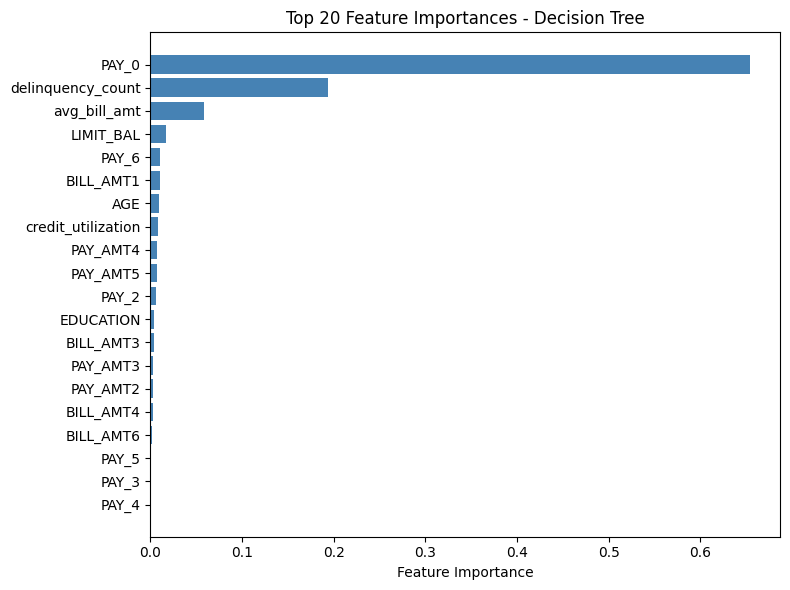

In [26]:
plot_feature_importances(dt_grid.best_estimator_, "Decision Tree")

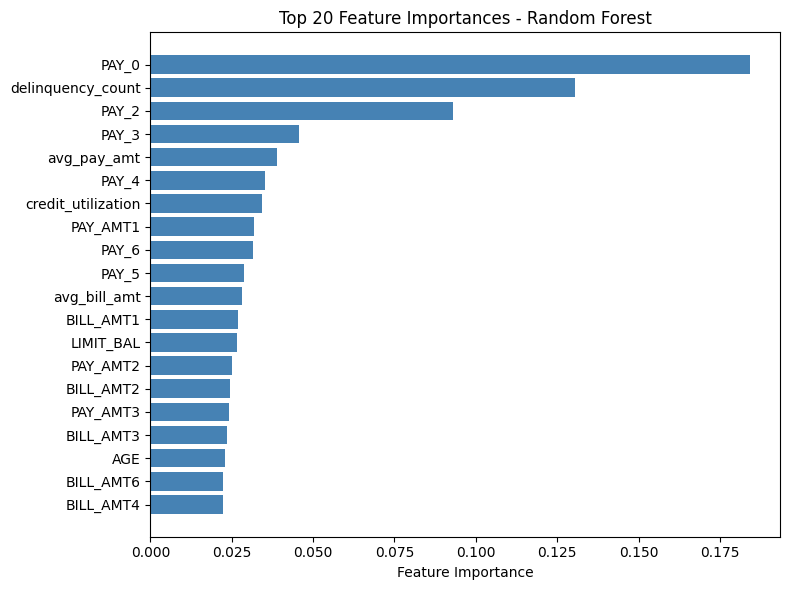

In [27]:
plot_feature_importances(rf_random.best_estimator_, "Random Forest")

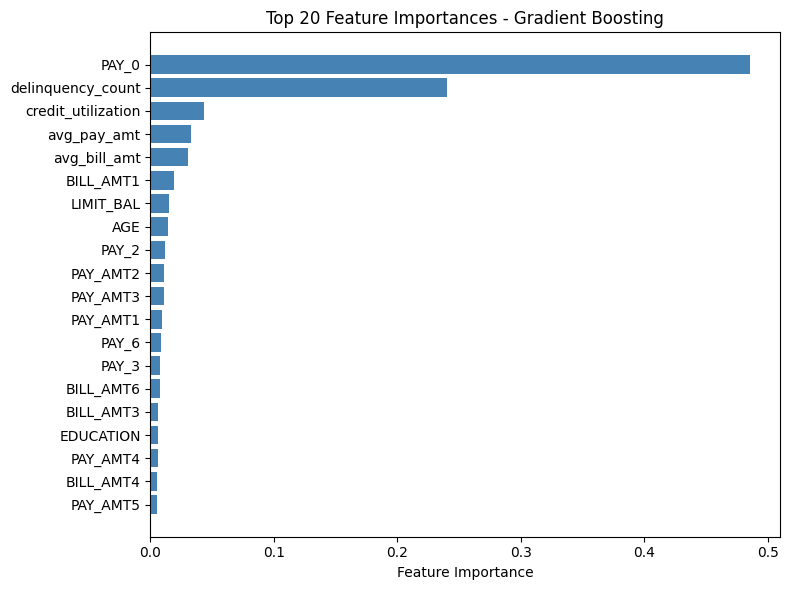

In [28]:
plot_feature_importances(gb_grid.best_estimator_, "Gradient Boosting")


# Summary: 
Overall, it is clear that PAY_0 contributes the most towards predictions. PAY_X represents the payment status for that month. So for PAY_0, it would indicate the payment status for that months bill. From this, we can draw that the payment status of the first month is a reliable factor to consider when considering if a client will default or not. Subsequent months (PAY_2, PAY_3 etc.) also seem to pay a roll, but in a generally decreasing amount in prediction.In a similar sense, delinquency_count, which measured the number of times the payment was missed was also quite significant. 

Additionally, LIMIT_BAL also seemed to have a reasonable contribution to predictions across all models. This indicates that higher credit limits promtes greater spending, which may be difficult for some indivdiuals to pay off. Leading to credit card defaults. 

Personal inforation like age and education, while not irrelevant, seemed to have less of a singificance compared to payment history. 

However, what most interested me was the high concentration of collated features (avgs etc.) having a notable influence in graident boost prediction. Perhaps this focus on more derived values from feature engineering contributed to a stronger scoring roc-auc score. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

In [29]:

best_model = gb_grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_prob)
test_f1  = f1_score(y_test, y_pred, average="weighted")

print("Gradient Boosting result")
print(f"Test roc-auc : {test_auc}")
print(f"Test F1      : {test_f1}")
print(f"Best CV AUC  : {gb_grid.best_score_}")
print(classification_report(y_test, y_pred, target_names=["No Default", "Default"]))

Gradient Boosting result
Test roc-auc : 0.7835167124592788
Test F1      : 0.8021225888100799
Best CV AUC  : 0.784024874893192
              precision    recall  f1-score   support

  No Default       0.85      0.94      0.89      7052
     Default       0.65      0.38      0.48      1948

    accuracy                           0.82      9000
   macro avg       0.75      0.66      0.68      9000
weighted avg       0.80      0.82      0.80      9000



2. 

Comparing the produced test score of 0.7835167124592788 through the Gradient Boost model with other models, decision tree (0.7578) and random forest (0.7823), we can observe that there is a slightly higher score. 
The consistency between validation and test scores gives reasonable confidence in the model. However, since hyperparameter tuning was performed using CV on the training set, there is some degree of  optimization bias.

In [30]:
shap.initjs()

preprocessor = best_model[:-1]
gb_model = best_model[-1]

X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
X_test_prepared = pd.DataFrame(X_test_transformed, columns=feature_names)

explainer = shap.TreeExplainer(gb_model)

examples_to_explain = X_test_prepared.iloc[[10]]
shap_values = explainer.shap_values(examples_to_explain)

print("client")
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    examples_to_explain.iloc[0, :]
)


client


3. 
For this client we can observe:
- PAY_0: Pushes the prediction towards a higher (positive, default-prone) prediction value the most. 
- So, payments in the first month influences clients to be less default-prone

-- 
- delinquency_count: Follows PAY_0 to push a positive class prediction.
- This indicates that the following payments missed after PAY_0 also contributes to default behavior. But not as much as PAY_0.

--
- LIMIT_BAL: For this client, credit limit played less of a role. But still did contribute to a positive prediction

--
- The "higher" the red features push the value, the more likely the model predicts a positive class (will default prediction)
- The "lower" the blue features push the value, the more likely the model predicts a neagtive class (will not default prediciton)

--
- Overall, the model is confident that this client will default on their payments

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

In [31]:
best_models = {
    "Decision Tree": dt_grid.best_estimator_,
    "Random Forest": rf_random.best_estimator_,
    "Gradient Boost": gb_grid.best_estimator_,
}

print("Final eval:")
for name, model in best_models.items():
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    auc         = roc_auc_score(y_test, y_pred_prob)
    print(f"  {name} Test score: {auc}")





Final eval:
  Decision Tree Test score: 0.7577983323646807
  Random Forest Test score: 0.7822540185492107
  Gradient Boost Test score: 0.7835167124592788


1. 
| Model Used | Validation score| Test scores | Key Observations |
|---|---| ---|---|
| Logistic Regression | 0.756923 |0.7548838507999023 | Baseline linear modet. Worst roc-auc score of the four, suggesting the data has non-linear relationships that it cannot capture. Low varience between validation and test score, meaning no overfitting. |
| Decision Tree | 0.7593615815224722 |0.7577983323646807 | Very small improvement over logistic regression. Prone to overfitting without max_depth hyperparameter tuning. Low varience between validation and test score, meaning no overfitting. |
| Random Forest | 0.7828648117968133 |0.7822540185492107 | Strong performance. Outperforms single-tree models by reducing variance through the use of multiple trees as an ensemble model. Low varience between validation and test score, meaning no overfitting.|
| Gradient Boost | 0.784024874893192 |0.7835167124592788 | Highest roc-auc scoring overall; slightly beats Random Forest, though at the cost of longer training time. Also had the lowest variance between test and train score, suggesting very good generalization. Low varience between validation and test score, meaning no overfitting.|


2. 
Overall, I think this project was an interesting way to apply all of the lecture materials up until now. I was able to conduct data exploration, preprocessing, and critique the different models. One of the many things that I did that worked out was to utilize scoring="auc_roc". AUC_ROC was the best choice for a metric as it performs very well on unbalanced classes, as was the case with the credit card data set. Another thing that worked out was the feature analysis I conducted. Specifically, I was able to visually observe which of the features were central in driving the model. From this, I was also able to reasonably conclude that the payment status of the first month is a strong indicator of default behavior. This makes logical sense, as if a client is unable to make their first payment, what is to say they will ever will? 

--

While I did have my strong points, one shortcoming was that I did not utilize SHAP to display feature importances. SHAP would have been advantagous as the visuals it produces is highly interpretable and would make it easier for understanding how my preidction model worked. Another thing that didn't really work out was to make use of both decision tree's and random forest. While different models, they both fundamentally work the same and as such, the diversity of model types in your comparison is limited. Selecting a model that is based on a completely seperate philosophy may have produced a stronger model. 

3. 
- Class imbalance handling: Other techniques of handling class imbalance can be used to improve recall on the default class. 
- Adding additional features through feature engineering: Looking at what features were used the most, we can build upon those and create additional features to improve prediction accuracy.
- Additional advanced models can be added: We can implement and observe other prediction models to possibily find one that performs better than the Graidient Boost we have now. 
- Utilization of SHAP to produce more visually interpretable graphs for feature importance observation
- Conduct further feature engineering to reduce the number of columns, especially with PAY_X and BILL_AMT_X as it caused data clutter and hurt interpretability. 

4. 
- Final test score: 0.7835167124592788
- Metric used: ROC-AUC

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

My biggest takeaway from the material we have learned so far is the importance of understanding all the tools we are given. What that means is that we are given functions and shortcuts by Python and the respective libraries, but in the end, we are the ones that must use our knowledge of the tools in order to construct meaningful and effective prediction models. We must also make reasonable choices in taking additional steps for certain data sets, such as the various scaling methods available and imputation. This is not something Python will do on its own, but it is something we have to decide and implement in our prediction workflow as necessary.

For instance, even in this assignment, we had to inspect the three non-linear models and how they performed. The metrics we were given had to be interpreted by our knowledge, and this would not have been possible without the understanding of what the metrics actually represent. High train_score may look desireble, but in the context of decisiont ree and randomized forest, we know that it is something to be cautious about due to overfitting. 

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please ensure you have followed all the steps in the **Instructions** section at the top.  

### Submission checklist  

- [ ] Restart the kernel and run all cells (▶▶ button)
- [ ] Make sure to push the most up to date version of your homework assignment to your GitHub repository so that we can use it for grading if there are any problems with your submission on Gradescope. 
- [ ] The `.ipynb` file runs without errors and shows all outputs.  
- [ ] Only the `.ipynb` file and required output files are uploaded (no extra files).  
- [ ] If the `.ipynb` file is too large to render on Gradescope, upload a Web PDF and/or HTML version as well.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)